In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

import pandas as pd
import networkx as nx
import scipy.stats as stats

from utils.graph_fns import read_graph_mastodon,get_all_trees,get_tagged_trees,align_times,get_branches_tree
from utils.graph_fns import combine_trees,add_fluo_to_graph
# remove warnings from mastodon
import warnings
warnings.filterwarnings('ignore', message='.+Unkown Mastodon feature.+', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas.+', category=FutureWarning)

# fig 4 with new data 

In [10]:
import pickle
import os 
# create the output data file
exps_file = './output_data/62_alldat.bin'

if os.path.isfile(exps_file):
    with open(exps_file,'rb') as f:
        exps = pickle.load(f)
else: 
    # #compare two conditions
    exps = {}
    exps['control']= {'file_tracks':'../data/transfection/2/control/well_B2_merged_6.mastodon',
                        'file_fluo':'../data/transfection/2/control/fluo_B2_basic_s0.1.bin',
                        'tags': ('untracked','verified'),
                        }
    exps['500uM_2'] = {'file_tracks':'../data/transfection/2/500um_rep/BDV_well_C5_4.mastodon',
                    'file_fluo':'../data/transfection/2/500um_rep/fluo_C5_basic_s0.1.bin',
                    #'tags': ('untracked',),
            }
    # this one currently doesn't work because according to my code, the resulting
    # trees do not form a "branching", maybe you can remove 

    # exps['500uM']= {'file_tracks':'../data/transfection/2/500um/well_B5_merged_12.ome.tif.mastodon',
    #                   'file_fluo':'../data/transfection/2/500um/fluo_B5_basic_s0.1.bin',
    #         }

    exps['control_2']= {'file_tracks':'../data/transfection/2/control_rep/well_C2_t0-500_20frames_r50-75-75.mastodon',
                    'file_fluo':'../data/transfection/2/control_rep/fluo_C2_basic_s0.1.bin',
                    'tags': ('untracked','verified'),
            }
    # do some preprocessing

    for e in exps:
        dat = exps[e]
        if dat.get('processed'):
            continue
        dat['graph'],dat['spots'],dat['links'],dat['tag_definition'] = read_graph_mastodon(dat['file_tracks'])
        dat['spots']['t'] = dat['spots']['t'].astype(int)
        dat['spots']['frame'] = dat['spots']['t']//18
        dat['time'] = pd.read_csv('../data/transfection/2/10um/62pd_delta_times.csv',index_col=0)
        dat['spots']['secs'] = dat['time'].loc[dat['spots']['t']].values
        if 'tags' in dat:
            # retrieve only tagged trees
            dat['trees'] = get_tagged_trees(dat['graph'],dat['spots'],dat['tags'])
        else: 
            # retrieve all trees (because they are all GT tracks)
            dat['trees'] = get_all_trees(dat['graph'])
        df_fluo = pd.read_pickle(dat['file_fluo'])
        graph = combine_trees(dat['trees'])
        graph,spots = add_fluo_to_graph(graph,dat['spots'],df_fluo)
        dat['graph_fluo'] = graph
        dat['spots_fluo'] = spots
        dat['processed'] = True
        print(f'{e} processed')
    # one time only 
    with open(exps_file,'wb') as f :
        pickle.dump(exps,f)


deleting 3 nodes
deleting 32 nodes
control processed
deleting 16 nodes
control_2 processed


control: removed 3 interrupted tracks


/tmp/ipykernel_137105/778856559.py:30: RuntimeWarning: divide by zero encountered in divide
  v = np.sqrt(  (x[1:] - x[:-1])**2 + (y[1:] - y[:-1])**2  ) /(t[1:] - t[:-1])
/tmp/ipykernel_137105/778856559.py:30: RuntimeWarning: divide by zero encountered in divide
  v = np.sqrt(  (x[1:] - x[:-1])**2 + (y[1:] - y[:-1])**2  ) /(t[1:] - t[:-1])


control_2: removed 2 interrupted tracks


/tmp/ipykernel_137105/778856559.py:30: RuntimeWarning: divide by zero encountered in divide
  v = np.sqrt(  (x[1:] - x[:-1])**2 + (y[1:] - y[:-1])**2  ) /(t[1:] - t[:-1])
/tmp/ipykernel_137105/778856559.py:30: RuntimeWarning: divide by zero encountered in divide
  v = np.sqrt(  (x[1:] - x[:-1])**2 + (y[1:] - y[:-1])**2  ) /(t[1:] - t[:-1])


500uM_2: removed 3 interrupted tracks


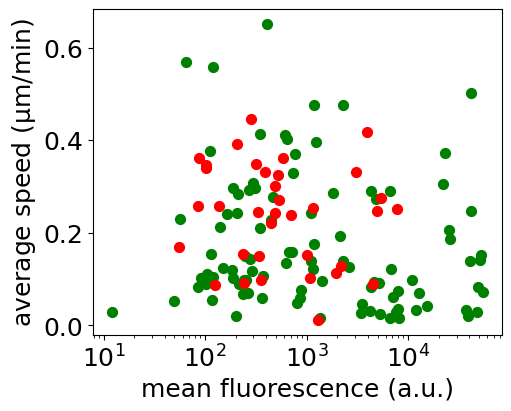

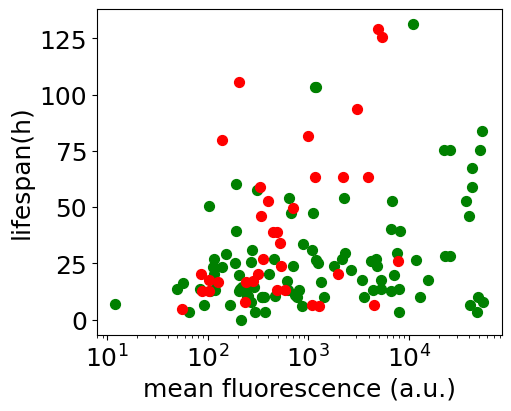

In [73]:
# keys indicating that a track has ended for some reason
end_track_keys = {'untracked','untraced'}

for e in exps:
    dat = exps[e]
    newspots = dat['spots_fluo'].copy()
    graph = dat['graph_fluo'].copy()
    # retrieve branches (my way might not be ideal)
    branches = get_branches_tree(graph)
    removed_tracks = 0 
    for i,nodes in enumerate(branches):
        # get the track
        traj = newspots.loc[nodes]
        # and make sure that we only get spots when light is shining
        cnd = traj['t'] % 18 == 0
        #print(len(traj), sum(cnd))
        traj = traj[cnd]
        nodes = traj.index
        
         # remove untracked cells
        if any( graph.nodes[n].get(v+'_NAME','') != '' for n in nodes.to_list()
                                                for v in end_track_keys):
            removed_tracks += 1 
            continue 
        if len(traj) < 2: # some tracks are too short
            continue
        
        x,y,t = traj.x.to_numpy(),traj.y.to_numpy(), traj.secs.to_numpy()/60
        assert len(x) == len(y) == len(t)
        v = np.sqrt(  (x[1:] - x[:-1])**2 + (y[1:] - y[:-1])**2  ) /(t[1:] - t[:-1])
        v = np.concatenate([[0],v])
        # need to lcassify track 
        newspots.loc[nodes,'speed'] = v
        newspots.loc[nodes,'track_id_plot'] = i# ['intensity_max'].mean()
    
    if removed_tracks : print(f'{e}: removed {removed_tracks} interrupted tracks')


    # not sure if this is necessary but I want to remove unassigned spots
    newspots = newspots.dropna() 
    alltracks_intensity = newspots.groupby('track_id_plot')['intensity_max'].mean()
    alltracks_speed = newspots.groupby('track_id_plot')['speed'].mean()
    lifespans = newspots.groupby('track_id_plot')['secs'].max() - newspots.groupby('track_id_plot')['secs'].min()
    lifespans/= 3600.0 # put in hours

    dat['intensity'] = alltracks_intensity
    dat['speed'] = alltracks_speed
    dat['lifespan'] = lifespans



fig, ax = plt.subplots(figsize=(5,4),layout='constrained')


for e in exps:
    dat = exps[e]
    color = 'green' if 'control' in e.lower() else 'red'
    label = e
    ax.scatter(dat['intensity'],dat['speed'],color=color,label=label,s=50)
    ax.set_xscale('log')
    ax.set_xlabel('mean fluorescence (a.u.)',)
    ax.set_ylabel('average speed ($\mathrm{\mu}$m/min)')

plt.savefig('../figures/plots/scatter_mean_fluo_vs_speed_revised.svg')

fig, ax = plt.subplots(figsize=(5,4),layout='constrained')
for e in exps:
    dat = exps[e]
    color = 'green' if 'control' in e.lower() else 'red'
    label = e
    ax.scatter(dat['intensity'],dat['lifespan'],color=color,label=label,s=50)
    ax.set_xscale('log')
    ax.set_xlabel('mean fluorescence (a.u.)',)
    ax.set_ylabel('lifespan(h)')

plt.savefig('../figures/plots/scatter_mean_fluo_vs_lifespan_revised.svg')

Statstics

In [ ]:
from scipy.stats import pearsonr
from glob import glob
import ndtest 
for ylab in ('lifespan','speed'):
    xlab = 'intensity'
    xs,ys,xs1,ys1 = [],[],[],[]
    print(f'{xlab} vs {ylab}')
    for e in exps:
      x = exps[e][xlab]
      y = exps[e][ylab]
      # some speed might be infinite, discard them
      x,y = x[np.isfinite(y)],y[np.isfinite(y)]
      if 'control' in e.lower():
        xs.append(x)
        ys.append(y)
      else: 
        xs1.append(x)
        ys1.append(y)
    xs = np.concatenate(xs)
    ys = np.concatenate(ys)
    xs1= np.concatenate(xs1)
    ys1 = np.concatenate(ys1)

    P, D = ndtest.ks2d2s(xs,ys,xs1,ys1, extra=True)
    #print(f)# {P=:.3g}, {D=:.3g}")
    print(f"2D pearson: {P=:.3g}, {D=:.3g}")
    print(f'pearson control {pearsonr(xs,ys)}')
    print(f'pearson treated {pearsonr(xs1,ys1)}')
    #, track_lens

intensity vs lifespan
2D pearson: P=0.0667, D=0.274
pearson control PearsonRResult(statistic=0.2883611124018659, pvalue=0.002992535992825111)
pearson treated PearsonRResult(statistic=0.4091355071586822, pvalue=0.01192362578248318)
intensity vs speed
2D pearson: P=0.0123, D=0.338
pearson control PearsonRResult(statistic=-0.09815518834638702, pvalue=0.32394014440579216)
pearson treated PearsonRResult(statistic=0.018728557408682286, pvalue=0.9123928691733808)
